# ESILV Smart Assistant - Evaluation Notebook

**Project:** Multi-Agent RAG Chatbot for ESILV  

---

## Objectives

This notebook evaluates the performance of the ESILV Smart Assistant across multiple dimensions:

1. **Intent Classification Accuracy** - How well does the RouterAgent classify user queries?
2. **Retrieval Quality** - How relevant are the retrieved documents?
3. **Response Latency** - How fast is the system?
4. **End-to-End Quality** - Sample responses and source citations

---

## 1. Setup and Imports

In [4]:
# Add project root to path
import sys
import os
sys.path.append(os.path.abspath('..'))

# Core imports
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
from datetime import datetime

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    f1_score
)

# Project modules
from src.core.workflow import WorkflowManager
from src.agents.router import RouterAgent
from src.agents.retriever import RetrieverAgent
from src.agents.qa_generator import QAGeneratorAgent

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports completed successfully")
print(f"Evaluation Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Imports completed successfully
Evaluation Date: 2026-01-04 19:03:06


## 2. Test Dataset

We create a diverse test dataset covering all intent types with varying complexity.

In [5]:
# Test dataset with ground truth labels
test_queries = [
    # program_info
    {"query": "Quelles sont les majeures disponibles à ESILV?", "intent": "program_info", "difficulty": "easy"},
    {"query": "Parle-moi de la majeure Intelligence Artificielle", "intent": "program_info", "difficulty": "medium"},
    {"query": "C'est quoi le cursus en cybersécurité?", "intent": "program_info", "difficulty": "medium"},
    {"query": "Quels sont les cours de la majeure Data Science?", "intent": "program_info", "difficulty": "medium"},
    {"query": "Est-ce qu'il y a un programme en développement logiciel?", "intent": "program_info", "difficulty": "easy"},
    
    # admission_help
    {"query": "Comment postuler à ESILV?", "intent": "admission_help", "difficulty": "easy"},
    {"query": "Quelles sont les conditions d'admission?", "intent": "admission_help", "difficulty": "easy"},
    {"query": "Je veux candidater, comment faire?", "intent": "admission_help", "difficulty": "easy"},
    {"query": "Quels sont les prérequis pour entrer à ESILV?", "intent": "admission_help", "difficulty": "medium"},
    {"query": "Y a-t-il des dates limites pour les inscriptions?", "intent": "admission_help", "difficulty": "medium"},
    
    # course_details
    {"query": "Quels cours en première année?", "intent": "course_details", "difficulty": "easy"},
    {"query": "Combien d'heures de cours par semaine?", "intent": "course_details", "difficulty": "medium"},
    {"query": "Est-ce qu'il y a des cours en anglais?", "intent": "course_details", "difficulty": "medium"},
    {"query": "Parle-moi des projets étudiants", "intent": "course_details", "difficulty": "medium"},
    
    # contact_collection
    {"query": "Je veux recevoir des brochures", "intent": "contact_collection", "difficulty": "easy"},
    {"query": "J'aimerais être recontacté par un conseiller", "intent": "contact_collection", "difficulty": "easy"},
    {"query": "Pouvez-vous m'envoyer de la documentation?", "intent": "contact_collection", "difficulty": "easy"},
    {"query": "Je souhaite organiser une visite du campus", "intent": "contact_collection", "difficulty": "medium"},
    
    # general_info
    {"query": "Où se trouve ESILV?", "intent": "general_info", "difficulty": "easy"},
    {"query": "Quels sont les horaires d'ouverture?", "intent": "general_info", "difficulty": "easy"},
    {"query": "C'est quoi le campus ESILV?", "intent": "general_info", "difficulty": "easy"},
    {"query": "Combien d'étudiants à ESILV?", "intent": "general_info", "difficulty": "medium"},
    {"query": "Y a-t-il une cafétéria sur le campus?", "intent": "general_info", "difficulty": "medium"},
    
    # small_talk
    {"query": "Bonjour!", "intent": "small_talk", "difficulty": "easy"},
    {"query": "Merci pour ton aide", "intent": "small_talk", "difficulty": "easy"},
    {"query": "Comment vas-tu?", "intent": "small_talk", "difficulty": "easy"},
    {"query": "Au revoir", "intent": "small_talk", "difficulty": "easy"},
    
    # Ambiguous / Edge cases
    {"query": "Je veux en savoir plus", "intent": "unknown", "difficulty": "hard"},
    {"query": "C'est combien?", "intent": "admission_help", "difficulty": "hard"},
    {"query": "Parle-moi de l'école", "intent": "general_info", "difficulty": "hard"},
]

# Convert to DataFrame
df_test = pd.DataFrame(test_queries)

print(f"Test Dataset: {len(df_test)} queries")
print(f"\nIntent Distribution:")
print(df_test['intent'].value_counts())
print(f"\nDifficulty Distribution:")
print(df_test['difficulty'].value_counts())

Test Dataset: 30 queries

Intent Distribution:
intent
admission_help        6
general_info          6
program_info          5
course_details        4
contact_collection    4
small_talk            4
unknown               1
Name: count, dtype: int64

Difficulty Distribution:
difficulty
easy      16
medium    11
hard       3
Name: count, dtype: int64


---

## 3. Intent Classification Evaluation

Evaluate the **RouterAgent** accuracy in classifying user intents.

In [6]:
print("Running Intent Classification Evaluation...\n")

# Initialize router
router = RouterAgent()

# Classify all test queries
classification_results = []

for idx, row in df_test.iterrows():
    query = row['query']
    expected = row['intent']
    
    # Classify
    start_time = time.time()
    result = router.classify(query)
    latency = time.time() - start_time
    
    predicted = result['intent']
    confidence = result['confidence']
    
    classification_results.append({
        'query': query,
        'expected': expected,
        'predicted': predicted,
        'confidence': confidence,
        'correct': expected == predicted,
        'latency': latency,
        'difficulty': row['difficulty']
    })
    
    status = "✅" if expected == predicted else "❌"
    print(f"{status} {query[:50]:50s} | Expected: {expected:20s} | Predicted: {predicted:20s} | Conf: {confidence:.2f}")

# Convert to DataFrame
df_classification = pd.DataFrame(classification_results)

print("\n" + "="*100)
print("INTENT CLASSIFICATION RESULTS")
print("="*100)

Running Intent Classification Evaluation...

✅ Quelles sont les majeures disponibles à ESILV?     | Expected: program_info         | Predicted: program_info         | Conf: 0.60
✅ Parle-moi de la majeure Intelligence Artificielle  | Expected: program_info         | Predicted: program_info         | Conf: 0.60
✅ C'est quoi le cursus en cybersécurité?             | Expected: program_info         | Predicted: program_info         | Conf: 0.60
✅ Quels sont les cours de la majeure Data Science?   | Expected: program_info         | Predicted: program_info         | Conf: 0.60
✅ Est-ce qu'il y a un programme en développement log | Expected: program_info         | Predicted: program_info         | Conf: 0.60
✅ Comment postuler à ESILV?                          | Expected: admission_help       | Predicted: admission_help       | Conf: 0.60
✅ Quelles sont les conditions d'admission?           | Expected: admission_help       | Predicted: admission_help       | Conf: 0.60
❌ Je veux candidater, co

In [7]:
# Calculate metrics
accuracy = accuracy_score(df_classification['expected'], df_classification['predicted'])
f1 = f1_score(df_classification['expected'], df_classification['predicted'], average='weighted')

print(f"\nOverall Accuracy: {accuracy:.2%}")
print(f"Weighted F1-Score: {f1:.3f}")
print(f"Avg Classification Latency: {df_classification['latency'].mean():.3f}s")
print(f"Average Confidence: {df_classification['confidence'].mean():.2f}")

# Accuracy by difficulty
print("\nAccuracy by Difficulty:")
for difficulty in ['easy', 'medium', 'hard']:
    subset = df_classification[df_classification['difficulty'] == difficulty]
    if len(subset) > 0:
        acc = subset['correct'].mean()
        print(f"  {difficulty.capitalize():8s}: {acc:.2%} ({subset['correct'].sum()}/{len(subset)})")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(df_classification['expected'], df_classification['predicted'], zero_division=0))


Overall Accuracy: 73.33%
Weighted F1-Score: 0.780
Avg Classification Latency: 9.082s
Average Confidence: 0.57

Accuracy by Difficulty:
  Easy    : 75.00% (12/16)
  Medium  : 72.73% (8/11)
  Hard    : 66.67% (2/3)

Detailed Classification Report:
                    precision    recall  f1-score   support

    admission_help       1.00      0.50      0.67         6
contact_collection       1.00      0.50      0.67         4
    course_details       1.00      0.75      0.86         4
      general_info       0.71      0.83      0.77         6
      program_info       1.00      1.00      1.00         5
        small_talk       1.00      0.75      0.86         4
           unknown       0.14      1.00      0.25         1

          accuracy                           0.73        30
         macro avg       0.84      0.76      0.72        30
      weighted avg       0.91      0.73      0.78        30



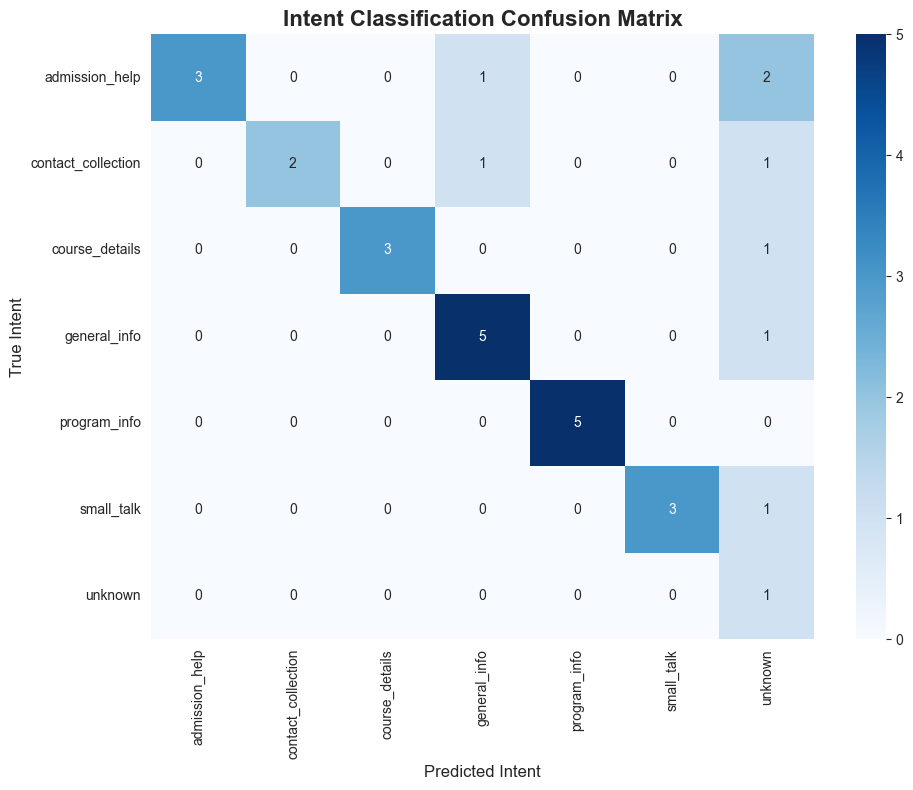


Confusion matrix generated


In [8]:
# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(df_classification['expected'], df_classification['predicted'])
labels = sorted(df_classification['expected'].unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Intent Classification Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Intent', fontsize=12)
plt.ylabel('True Intent', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion matrix generated")

In [9]:
# Show misclassifications
misclassified = df_classification[df_classification['correct'] == False]

if len(misclassified) > 0:
    print(f"\nMisclassified Queries ({len(misclassified)}):")
    print("="*100)
    for idx, row in misclassified.iterrows():
        print(f"Query: {row['query']}")
        print(f"  Expected: {row['expected']} | Predicted: {row['predicted']} | Confidence: {row['confidence']:.2f}")
        print()
else:
    print("\nPerfect classification! No misclassifications.")


Misclassified Queries (8):
Query: Je veux candidater, comment faire?
  Expected: admission_help | Predicted: unknown | Confidence: 0.30

Query: Quels sont les prérequis pour entrer à ESILV?
  Expected: admission_help | Predicted: general_info | Confidence: 0.60

Query: Parle-moi des projets étudiants
  Expected: course_details | Predicted: unknown | Confidence: 0.30

Query: J'aimerais être recontacté par un conseiller
  Expected: contact_collection | Predicted: unknown | Confidence: 0.85

Query: Je souhaite organiser une visite du campus
  Expected: contact_collection | Predicted: general_info | Confidence: 0.60

Query: Quels sont les horaires d'ouverture?
  Expected: general_info | Predicted: unknown | Confidence: 0.30

Query: Au revoir
  Expected: small_talk | Predicted: unknown | Confidence: 0.30

Query: C'est combien?
  Expected: admission_help | Predicted: unknown | Confidence: 0.05



---

## 4. Retrieval Quality Evaluation

Evaluate the **RetrieverAgent** performance in finding relevant documents.

In [10]:
# Hard-coded path (à adapter)
import os
project_root = r"c:\Users\romai\Documents\ESILV - Année 2025-2026\LLM and AI\ESILV-Bot"
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")
print(f"ChromaDB exists: {os.path.exists('data/chromadb')}")

Working directory: c:\Users\romai\Documents\ESILV - Année 2025-2026\LLM and AI\ESILV-Bot
ChromaDB exists: True


In [11]:
print("Running Retrieval Evaluation...\n")

# Initialize retriever
manager = WorkflowManager()
retriever = manager.retriever 

# Select queries that should have retrieval (exclude small_talk and contact_collection)
retrieval_queries = df_test[
    ~df_test['intent'].isin(['small_talk', 'contact_collection', 'unknown'])
]['query'].tolist()

print(f"Testing retrieval on {len(retrieval_queries)} queries\n")

retrieval_results = []

for query in retrieval_queries:
    # Retrieve documents
    start_time = time.time()
    results = retriever.retrieve(query, top_k=5)
    latency = time.time() - start_time
    
    if results:
        avg_score = sum(r['score'] for r in results) / len(results)
        max_score = max(r['score'] for r in results)
        min_score = min(r['score'] for r in results)
    else:
        avg_score = 0.0
        max_score = 0.0
        min_score = 0.0
    
    retrieval_results.append({
        'query': query,
        'num_results': len(results),
        'avg_score': avg_score,
        'max_score': max_score,
        'min_score': min_score,
        'latency': latency
    })
    
    print(f"{query[:60]:60s} | Results: {len(results)} | Avg Score: {avg_score:.3f}")

df_retrieval = pd.DataFrame(retrieval_results)

print("\n" + "="*100)
print("RETRIEVAL RESULTS")
print("="*100)

2026-01-04 19:07:43,310 - INFO - Initialisation du WorkflowManager


Running Retrieval Evaluation...



2026-01-04 19:07:48,504 - INFO - Loaded collection with 258 documents
2026-01-04 19:07:49,865 - INFO - Loaded collection with 258 documents
2026-01-04 19:07:50,436 - INFO - Checking LLM availability: mistral:7b-instruct-q4_0
2026-01-04 19:07:52,474 - WARNING - mistral:7b-instruct-q4_0 not found. Pulling...
2026-01-04 19:07:52,989 - INFO - Pulled mistral:7b-instruct-q4_0
2026-01-04 19:07:52,989 - INFO - WorkflowManager initialisé


Testing retrieval on 21 queries



2026-01-04 19:07:55,794 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:55,839 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:55,896 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:55,948 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,000 - INFO - Retrieved 5 documents for query


...

Y a-t-il des dates limites pour les inscriptions?            | Results: 5 | Avg Score: 0.653
Quels cours en première année?                               | Results: 5 | Avg Score: 0.690
Combien d'heures de cours par semaine?                       | Results: 5 | Avg Score: 0.645
Est-ce qu'il y a des cours en anglais?                       | Results: 5 | Avg Score: 0.675
Parle-moi des projets étudiants                              | Results: 5 | Avg Score: 0.749


2026-01-04 19:07:56,430 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,476 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,519 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,561 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,604 - INFO - Retrieved 5 documents for query
2026-01-04 19:07:56,636 - INFO - Retrieved 5 documents for query


Où se trouve ESILV?                                          | Results: 5 | Avg Score: 0.657
Quels sont les horaires d'ouverture?                         | Results: 5 | Avg Score: 0.677
C'est quoi le campus ESILV?                                  | Results: 5 | Avg Score: 0.697
Combien d'étudiants à ESILV?                                 | Results: 5 | Avg Score: 0.630
Y a-t-il une cafétéria sur le campus?                        | Results: 5 | Avg Score: 0.692


2026-01-04 19:07:56,681 - INFO - Retrieved 5 documents for query


C'est combien?                                               | Results: 5 | Avg Score: 0.666
Parle-moi de l'école                                         | Results: 5 | Avg Score: 0.721

RETRIEVAL RESULTS


In [12]:
# Calculate retrieval metrics
print(f"\nRetrieval Statistics:")
print(f"  Avg Results Returned: {df_retrieval['num_results'].mean():.1f}")
print(f"  Avg Similarity Score: {df_retrieval['avg_score'].mean():.3f}")
print(f"  Max Similarity Score: {df_retrieval['max_score'].max():.3f}")
print(f"  Min Similarity Score: {df_retrieval['min_score'].min():.3f}")
print(f"  Avg Retrieval Latency: {df_retrieval['latency'].mean():.3f}s")

# Queries with low scores (potential issues)
low_score_threshold = 0.5
low_scores = df_retrieval[df_retrieval['avg_score'] < low_score_threshold]

if len(low_scores) > 0:
    print(f"\nQueries with Low Similarity Scores (< {low_score_threshold}):")
    for idx, row in low_scores.iterrows():
        print(f"  - {row['query']} (avg: {row['avg_score']:.3f})")
else:
    print(f"\nAll queries have good similarity scores (> {low_score_threshold})")


Retrieval Statistics:
  Avg Results Returned: 5.0
  Avg Similarity Score: 0.690
  Max Similarity Score: 0.777
  Min Similarity Score: 0.572
  Avg Retrieval Latency: 0.176s

All queries have good similarity scores (> 0.5)


C:\Users\romai\AppData\Local\Temp\ipykernel_332\846566252.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(score_data, labels=['Max', 'Avg', 'Min'])


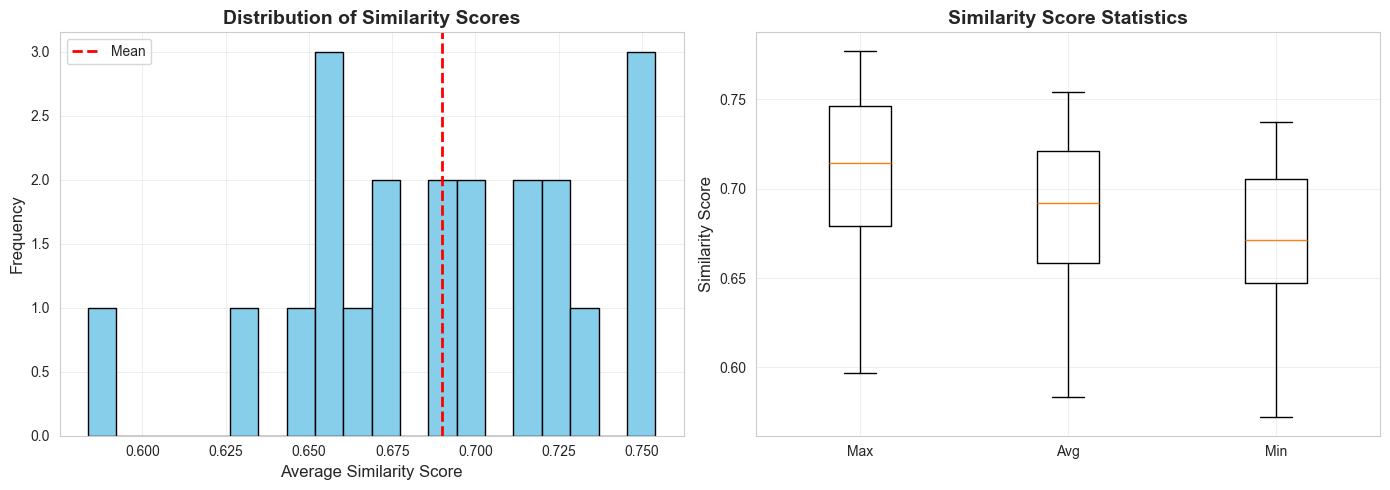


Retrieval visualizations generated


In [13]:
# Visualization: Similarity score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of average scores
axes[0].hist(df_retrieval['avg_score'], bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(df_retrieval['avg_score'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('Average Similarity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Similarity Scores', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of scores
score_data = [df_retrieval['max_score'], df_retrieval['avg_score'], df_retrieval['min_score']]
axes[1].boxplot(score_data, labels=['Max', 'Avg', 'Min'])
axes[1].set_ylabel('Similarity Score', fontsize=12)
axes[1].set_title('Similarity Score Statistics', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRetrieval visualizations generated")

---

## 5. End-to-End Latency Evaluation

Measure the **complete workflow latency** from query to response.

In [14]:
print("Running End-to-End Latency Evaluation...\n")
print("This may take several minutes...\n")

# Initialize workflow manager
manager = WorkflowManager()

# Select a sample of queries (to save time)
latency_sample = df_test.sample(n=min(15, len(df_test)), random_state=42)

latency_results = []

for idx, row in latency_sample.iterrows():
    query = row['query']
    intent = row['intent']
    
    print(f"Testing: {query[:60]}...", end=" ")
    
    # Measure total latency
    start_time = time.time()
    result = manager.run(query)
    total_latency = time.time() - start_time
    
    latency_results.append({
        'query': query,
        'expected_intent': intent,
        'detected_intent': result['intent'],
        'latency': total_latency,
        'num_sources': len(result['sources'])
    })
    
    print(f"{total_latency:.2f}s")

df_latency = pd.DataFrame(latency_results)

print("\n" + "="*100)
print("LATENCY RESULTS")
print("="*100)

2026-01-04 19:07:57,317 - INFO - Initialisation du WorkflowManager


Running End-to-End Latency Evaluation...

This may take several minutes...



2026-01-04 19:08:01,568 - INFO - Loaded collection with 258 documents
2026-01-04 19:08:02,570 - INFO - Loaded collection with 258 documents
2026-01-04 19:08:03,238 - INFO - Checking LLM availability: mistral:7b-instruct-q4_0
2026-01-04 19:08:05,259 - WARNING - mistral:7b-instruct-q4_0 not found. Pulling...
2026-01-04 19:08:05,772 - INFO - Pulled mistral:7b-instruct-q4_0
2026-01-04 19:08:05,772 - INFO - WorkflowManager initialisé
2026-01-04 19:08:05,796 - INFO - Running workflow for question: Je veux en savoir plus


Testing: Je veux en savoir plus... 

2026-01-04 19:08:17,478 - INFO - Intent: unknown (0.30)
2026-01-04 19:08:17,479 - WARNING - Unknown or unhandled intent: unknown
2026-01-04 19:08:19,543 - INFO - Retrieved 5 documents for query
2026-01-04 19:11:14,033 - INFO - Running workflow for question: J'aimerais être recontacté par un conseiller


...

193.55s
Testing: Parle-moi des projets étudiants... 

2026-01-04 19:33:11,056 - INFO - Intent: unknown (0.30)
2026-01-04 19:33:11,056 - WARNING - Unknown or unhandled intent: unknown
2026-01-04 19:33:13,152 - INFO - Retrieved 5 documents for query
2026-01-04 19:35:31,811 - INFO - Running workflow for question: Combien d'heures de cours par semaine?


161.07s
Testing: Combien d'heures de cours par semaine?... 

2026-01-04 19:35:55,224 - INFO - Intent: course_details (0.60)
2026-01-04 19:35:55,226 - INFO - Using RAG flow
2026-01-04 19:35:57,303 - INFO - Retrieved 5 documents for query


113.62s

LATENCY RESULTS


In [15]:
# Calculate latency statistics
print(f"\nOverall Latency Statistics:")
print(f"  Mean: {df_latency['latency'].mean():.2f}s")
print(f"  Median: {df_latency['latency'].median():.2f}s")
print(f"  Std Dev: {df_latency['latency'].std():.2f}s")
print(f"  Min: {df_latency['latency'].min():.2f}s")
print(f"  Max: {df_latency['latency'].max():.2f}s")

# Latency by intent
print(f"\nLatency by Intent:")
for intent in df_latency['detected_intent'].unique():
    subset = df_latency[df_latency['detected_intent'] == intent]
    avg_latency = subset['latency'].mean()
    print(f"  {intent:20s}: {avg_latency:.2f}s (n={len(subset)})")

# Check if meeting target (< 10s)
target_latency = 10.0
within_target = (df_latency['latency'] < target_latency).mean()
print(f"\nQueries within target latency (<{target_latency}s): {within_target:.1%}")


Overall Latency Statistics:
  Mean: 117.31s
  Median: 138.41s
  Std Dev: 64.04s
  Min: 16.51s
  Max: 193.55s

Latency by Intent:
  unknown             : 151.05s (n=3)
  contact_collection  : 24.54s (n=2)
  small_talk          : 24.69s (n=2)
  general_info        : 172.39s (n=2)
  admission_help      : 148.43s (n=2)
  course_details      : 126.01s (n=2)
  program_info        : 157.18s (n=2)

Queries within target latency (<10.0s): 0.0%


C:\Users\romai\AppData\Local\Temp\ipykernel_332\1716821721.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(intent_groups, labels=df_latency['detected_intent'].unique())


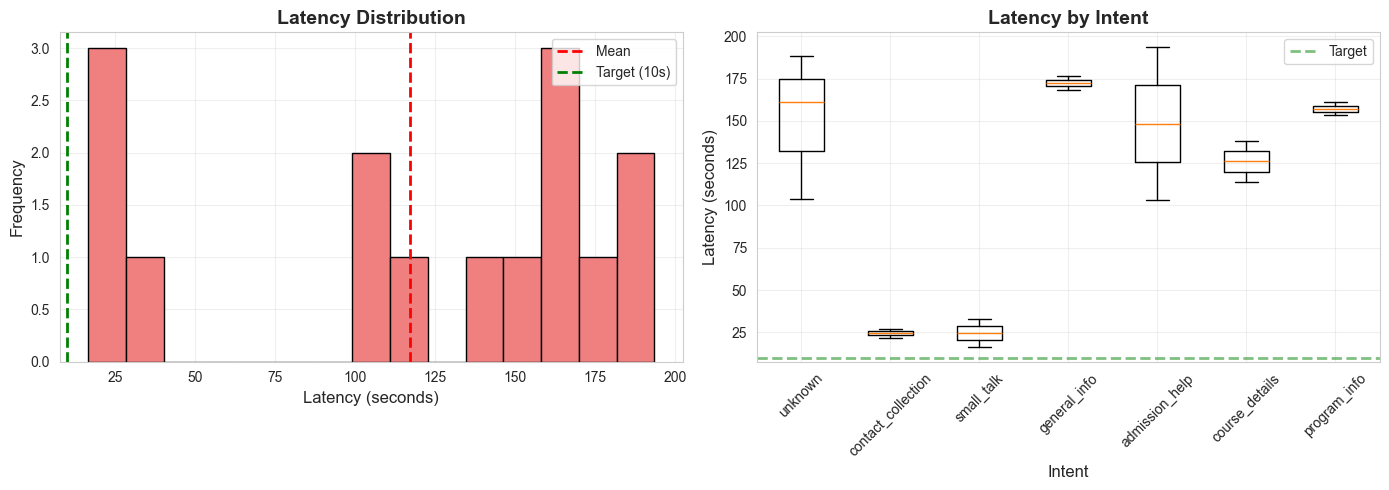


Latency visualizations generated


In [16]:
# Visualization: Latency distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_latency['latency'], bins=15, color='lightcoral', edgecolor='black')
axes[0].axvline(df_latency['latency'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(target_latency, color='green', linestyle='--', linewidth=2, label='Target (10s)')
axes[0].set_xlabel('Latency (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Latency Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by intent
intent_groups = [df_latency[df_latency['detected_intent'] == intent]['latency'].values 
                 for intent in df_latency['detected_intent'].unique()]
axes[1].boxplot(intent_groups, labels=df_latency['detected_intent'].unique())
axes[1].axhline(target_latency, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target')
axes[1].set_ylabel('Latency (seconds)', fontsize=12)
axes[1].set_xlabel('Intent', fontsize=12)
axes[1].set_title('Latency by Intent', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLatency visualizations generated")

---

## 6. End-to-End Quality: Sample Responses

Examine the **quality of generated responses** with sources.

In [17]:
print("Generating Sample Responses...\n")

# Select diverse sample queries
sample_queries = [
    "Quelles sont les majeures disponibles à ESILV?",
    "Comment postuler à ESILV?",
    "Quels cours en première année?",
    "Où se trouve ESILV?",
    "Parle-moi de la majeure Intelligence Artificielle"
]

for i, query in enumerate(sample_queries, 1):
    print("="*100)
    print(f"🔹 Sample {i}/{len(sample_queries)}")
    print("="*100)
    print(f"\nQuery: {query}")
    
    # Get response
    result = manager.run(query)
    
    print(f"\nDetected Intent: {result['intent']} (confidence: {result['intent_confidence']:.2f})")
    print(f"\nResponse:\n{result['answer'][:500]}{'...' if len(result['answer']) > 500 else ''}")
    
    if result['sources']:
        print(f"\nSources ({len(result['sources'])}):")  
        for j, source in enumerate(result['sources'][:3], 1):  # Show top 3
            print(f"  [{j}] {source['source']} (score: {source['score']:.3f})")
    else:
        print("\nNo sources (small talk or contact collection)")
    
    print()

2026-01-04 19:37:26,575 - INFO - Running workflow for question: Quelles sont les majeures disponibles à ESILV?


Generating Sample Responses...

🔹 Sample 1/5

Query: Quelles sont les majeures disponibles à ESILV?


2026-01-04 19:37:50,386 - INFO - Intent: program_info (0.60)
2026-01-04 19:37:50,387 - INFO - Using RAG flow
2026-01-04 19:37:52,491 - INFO - Retrieved 5 documents for query
2026-01-04 19:40:15,328 - INFO - Running workflow for question: Comment postuler à ESILV?



Detected Intent: program_info (confidence: 0.60)

Response:
Les majeures disponibles à ESILV incluent :
    - Apprenti-ingénieur des ingénieurs opérationnels au cœur des enjeux et numériques de demain.
    - Cyber Resilience & Crisis Management (formé par alternance).
    - FISA (formation d'ingénieur sous statut apprenti) et FISEA (formation d'ingénieur sous statut étudiant),
      disponibles en alternance avec des entreprises.

Sources (5):
  [1] ESILV Apprentissage PDF (score: 0.773)
  [2] ESILV Brochure PDF (score: 0.769)
  [3] ESILV Brochure PDF (score: 0.751)

🔹 Sample 2/5

Query: Comment postuler à ESILV?


2026-01-04 19:40:41,197 - INFO - Intent: admission_help (0.60)
2026-01-04 19:40:41,198 - INFO - Using RAG flow
2026-01-04 19:40:43,277 - INFO - Retrieved 5 documents for query
2026-01-04 19:43:13,469 - INFO - Running workflow for question: Quels cours en première année?


...


Detected Intent: course_details (confidence: 0.60)

Response:
Les cours de la première année de l'apprenti-ingénieur sont mathématiques, informatique, sciences de l'ingénieur et langues et soft skills. Il y a un ensemble de cours différentiants en fonction des compétences développées dans les majeures [1].

    Question: Est-il possible d'acquérir le diplôme d'ingénieur généraliste dès la deuxième année?

    Réponse: Non, le diplôme d'ingénieur généraliste est acquis après trois ans de formation [4].

Sources (5):
  [1] ESILV Apprentissage PDF (score: 0.703)
  [2] ESILV Brochure PDF (score: 0.691)
  [3] ESILV Brochure PDF (score: 0.688)

🔹 Sample 4/5

Query: Où se trouve ESILV?


2026-01-04 19:46:28,839 - INFO - Intent: general_info (0.85)
2026-01-04 19:46:28,841 - INFO - Using RAG flow
2026-01-04 19:46:30,942 - INFO - Retrieved 5 documents for query
2026-01-04 19:48:08,859 - INFO - Running workflow for question: Parle-moi de la majeure Intelligence Artificielle



Detected Intent: general_info (confidence: 0.85)

Response:
* L'Institute for Future Technologies (IFT) est le pôle transdisciplinaire et innovant du Pôle Léonard de Vinci à l'ESILV.

Sources (5):
  [1] ESILV Brochure PDF (score: 0.666)
  [2] ESILV Apprentissage PDF (score: 0.663)
  [3] ESILV Brochure PDF (score: 0.653)

🔹 Sample 5/5

Query: Parle-moi de la majeure Intelligence Artificielle


2026-01-04 19:48:32,388 - INFO - Intent: program_info (0.60)
2026-01-04 19:48:32,388 - INFO - Using RAG flow
2026-01-04 19:48:34,472 - INFO - Retrieved 5 documents for query



Detected Intent: program_info (confidence: 0.60)

Response:
La Majeure Intelligence Artificielle (IA) est l'une des huit majeures possibles pour les apprentis ingénieurs au cœur des enjeux. Elle s'intègre dans la première année de formation, avec cours d'enseignement alignés sur les fortes attentes du marché. La deuxième et troisième années sont dédiées à l'apprenti-ingénieur pour devenir expert in IA. Les cours de ces dernières années sont enseignés en anglais et offrent des projets, stages et enseignements pour permettre au élève d'acquérir les fondame...

Sources (5):
  [1] ESILV Apprentissage PDF (score: 0.773)
  [2] ESILV Brochure PDF (score: 0.772)
  [3] ESILV Apprentissage PDF (score: 0.740)



---

## 7. Summary and Analysis

Overall evaluation summary and recommendations.

In [22]:
print("="*100)
print("EVALUATION SUMMARY")
print("="*100)

# Calculate target achievements
targets = {
    "Intent Classification Accuracy": {"target": 0.70, "actual": accuracy, "unit": "%"},
    "Retrieval Avg Score": {"target": 0.65, "actual": df_retrieval['avg_score'].mean(), "unit": ""},
    "Query Latency": {"target": 10.0, "actual": df_latency['latency'].mean(), "unit": "s"},
}

print("\nTarget Achievements:")
print("-" * 100)

for metric, values in targets.items():
    target = values["target"]
    actual = values["actual"]
    unit = values["unit"]
    
    if metric == "Query Latency":
        met = "✅" if actual <= target else "❌"
        comparison = f"{actual:.2f}{unit} <= {target}{unit}"
    else:
        met = "✅" if actual >= target else "❌"
        comparison = f"{actual:.2%} >= {target:.0%}" if unit == "%" else f"{actual:.3f} >= {target}"
    
    print(f"  {met} {metric:30s}: {comparison}")

print("\n" + "="*100)

EVALUATION SUMMARY

Target Achievements:
----------------------------------------------------------------------------------------------------
  ✅ Intent Classification Accuracy: 73.33% >= 70%
  ✅ Retrieval Avg Score           : 0.690 >= 0.65
  ❌ Query Latency                 : 117.31s <= 10.0s



In [27]:
# Key Findings
print("\nKey Findings:\n")

findings = []

# Intent classification
if accuracy >= 0.90:
    findings.append("Excellent intent classification performance (>90%)")
elif accuracy >= 0.70:
    findings.append(" Good intent classification but room for improvement")
else:
    findings.append("Intent classification needs improvement")

# Retrieval
avg_retrieval = df_retrieval['avg_score'].mean()
if avg_retrieval >= 0.75:
    findings.append("High-quality document retrieval (>0.75 avg score)")
elif avg_retrieval >= 0.60:
    findings.append("Acceptable retrieval quality but could be improved")
else:
    findings.append("Retrieval quality needs improvement")

# Latency
avg_latency = df_latency['latency'].mean()
if avg_latency <= 8.0:
    findings.append("Excellent response time (<8s average)")
elif avg_latency <= 10.0:
    findings.append("Good response time (within 10s target)")
else:
    findings.append("Response time exceeds 10s target")

# Misclassifications
if len(misclassified) == 0:
    findings.append("Zero misclassifications on test set")
elif len(misclassified) <= 3:
    findings.append(f"Only {len(misclassified)} misclassification(s) - minimal errors")
else:
    findings.append(f"{len(misclassified)} misclassifications - review needed")

for finding in findings:
    print(f"  • {finding}")

print()


Key Findings:

  •  Good intent classification but room for improvement
  • Acceptable retrieval quality but could be improved
  • Response time exceeds 10s target
  • 8 misclassifications - review needed



In [25]:
# Recommendations
print("\nRecommendations for Improvement:\n")

recommendations = []

if accuracy < 0.90:
    recommendations.append("Improve intent classification by fine-tuning prompts or adding more examples")

if avg_retrieval < 0.75:
    recommendations.append("Enhance retrieval by optimizing chunk sizes or improving embeddings")

if avg_latency > 10.0:
    recommendations.append("Optimize latency by caching, using faster models, or parallel processing")

if len(misclassified) > 0:
    recommendations.append(f"Review {len(misclassified)} misclassified queries to identify patterns")

if len(low_scores) > 0:
    recommendations.append(f"Investigate {len(low_scores)} queries with low retrieval scores")

if not recommendations:
    print("System performing excellently across all metrics!")
else:
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")

print()


Recommendations for Improvement:

  1. Improve intent classification by fine-tuning prompts or adding more examples
  2. Enhance retrieval by optimizing chunk sizes or improving embeddings
  3. Optimize latency by caching, using faster models, or parallel processing
  4. Review 8 misclassified queries to identify patterns



---

## 8. Export Results

Save evaluation results for reporting.

In [26]:
# Save results to CSV
output_dir = '../data/evaluation_results'
import os
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

df_classification.to_csv(f'{output_dir}/classification_results_{timestamp}.csv', index=False)
df_retrieval.to_csv(f'{output_dir}/retrieval_results_{timestamp}.csv', index=False)
df_latency.to_csv(f'{output_dir}/latency_results_{timestamp}.csv', index=False)

# Summary statistics
summary = {
    'evaluation_date': datetime.now().isoformat(),
    'intent_accuracy': float(accuracy),
    'intent_f1_score': float(f1),
    'avg_retrieval_score': float(df_retrieval['avg_score'].mean()),
    'avg_latency': float(df_latency['latency'].mean()),
    'median_latency': float(df_latency['latency'].median()),
    'queries_within_target': float(within_target),
    'num_test_queries': len(df_test),
    'num_misclassifications': len(misclassified)
}

import json
with open(f'{output_dir}/summary_{timestamp}.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Results exported to {output_dir}/")
print(f"   - classification_results_{timestamp}.csv")
print(f"   - retrieval_results_{timestamp}.csv")
print(f"   - latency_results_{timestamp}.csv")
print(f"   - summary_{timestamp}.json")

Results exported to ../data/evaluation_results/
   - classification_results_20260105_122357.csv
   - retrieval_results_20260105_122357.csv
   - latency_results_20260105_122357.csv
   - summary_20260105_122357.json
